### __Week 8__ 

#### Loading the Network Graph

In [1]:
import pickle
import networkx as nx
import pandas as pd
import ast
from collections import Counter
import numpy as np

with open("G_social_compute.pkl", "rb") as f:
    G_social_compute = pickle.load(f)

tokenized_abstract = pd.read_csv('/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/social compute/Computational-Social-Science/tokenized_abstract.csv')
papers_dataset = pd.read_csv("/Users/keremozemre/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/social compute/Computational-Social-Science/more_than_one_author_papers_dataset.csv")
papers_dataset["author_ids"] = papers_dataset["author_ids"].apply(ast.literal_eval)

In [2]:
tokenized_abstract

,id,title,abstract_index,text,tokens
0,https://openalex.org/W1999649023,Statistical Methods for Meta-Analysis,"{'Preface.': [0], 'Introduction.': [1], 'Data'...",Preface. Introduction. Data Sets. Tests of Sta...,"['preface', 'introduction', 'data', 'sets', 't..."
1,https://openalex.org/W2055957857,Framing as a Theory of Media Effects,"{'Research': [0], 'on': [1], 'framing': [2, 25...",Research on framing is characterized by theore...,"['research', 'framing', 'characterized', 'theo..."
2,https://openalex.org/W3121315632,What Makes Online Content Viral?,"{'Why': [0], 'are': [1, 129], 'certain': [2], ...",Why are certain pieces of online content (e.g....,"['certain', 'pieces', 'online', 'content_eg', ..."
3,https://openalex.org/W2002781392,"Framing, Agenda Setting, and Priming: The Evol...","{'This': [0], 'special': [1], 'issue': [2], 'o...",This special issue of Journal of Communication...,"['special', 'issue', 'journal', 'communication..."
4,https://openalex.org/W2885869279,How to Do a Systematic Review: A Best Practice...,"{'Systematic': [0], 'reviews': [1, 54, 133, 15...",Systematic reviews are characterized by a meth...,"['systematic', 'reviews', 'characterized', 'me..."
...,...,...,...,...,...
167394,https://openalex.org/W2188156563,Predictability of Equity Returns over Differen...,NaN,NaN,NaN
167395,https://openalex.org/W2915560807,Understanding the Athena SWAN award scheme for...,"{'Abstract': [0], 'Background': [1], 'Given': ...",Abstract Background Given that the complex mix...,"['abstract_background', 'given', 'complex', 'm..."
167396,https://openalex.org/W4387301543,A Large Language Model-Based Generative Natura...,"{'Abstract': [0], 'Background': [1], 'Headache...","Abstract Background Headache frequency, define...","['abstract_background', 'headache', 'frequency..."
167397,https://openalex.org/W2945142372,Facebook-based social support and health: A sy...,"{'The': [0], 'rise': [1], 'of': [2, 34, 48, 55...",The rise of social networking sites (SNSs) hav...,"['rise_social', 'networking', 'sites', 'snss',..."


In [3]:
louvain_social_compute = nx.community.louvain_communities(G_social_compute,seed = 100)
social_compute_louvain_communities_size = {}
for i,community in enumerate(louvain_social_compute):
    social_compute_louvain_communities_size[i] = len(community)
social_compute_louvain_communities_size
    

{0: 362,
 1: 361,
 2: 98,
 3: 3,
 4: 318,
 5: 843,
 6: 494,
 7: 355,
 8: 32,
 9: 5,
 10: 262,
 11: 10,
 12: 8,
 13: 3,
 14: 12,
 15: 345,
 16: 140,
 17: 319,
 18: 4,
 19: 13,
 20: 380,
 21: 7,
 22: 5,
 23: 10,
 24: 3,
 25: 146,
 26: 287,
 27: 3,
 28: 22,
 29: 4,
 30: 61,
 31: 227,
 32: 19,
 33: 34,
 34: 208,
 35: 2,
 36: 13,
 37: 51,
 38: 3,
 39: 2,
 40: 21,
 41: 152,
 42: 6,
 43: 106,
 44: 8,
 45: 122,
 46: 3,
 47: 432,
 48: 267,
 49: 6,
 50: 10,
 51: 86,
 52: 161,
 53: 3,
 54: 738,
 55: 133,
 56: 5,
 57: 7,
 58: 32,
 59: 6,
 60: 4,
 61: 138,
 62: 400,
 63: 11,
 64: 7,
 65: 5,
 66: 7,
 67: 338,
 68: 5,
 69: 6,
 70: 5,
 71: 3,
 72: 7,
 73: 4,
 74: 116,
 75: 88,
 76: 6,
 77: 8,
 78: 7,
 79: 13,
 80: 5,
 81: 6,
 82: 7,
 83: 3,
 84: 276,
 85: 1306,
 86: 173,
 87: 42,
 88: 5,
 89: 10,
 90: 7,
 91: 8,
 92: 270,
 93: 3,
 94: 6,
 95: 36,
 96: 28,
 97: 119,
 98: 5,
 99: 5,
 100: 2,
 101: 33,
 102: 7,
 103: 8,
 104: 2,
 105: 179,
 106: 11,
 107: 4,
 108: 56,
 109: 3,
 110: 9,
 111: 181,
 112: 1

In [4]:
for community_id, community_nodes in enumerate(louvain_social_compute):
    for node in community_nodes:
        G_social_compute.nodes[node]['community'] = community_id

for node, deg in G_social_compute.degree():
    G_social_compute.nodes[node]['degree'] = deg

### Checking if the assignment is correct

In [6]:
G_social_compute.nodes['https://openalex.org/A5013693751']

{'display_name': 'Ingram Olkin',
 'country': 'US',
 'first_publication_year': 1988,
 'total_citations': 13344,
 'community': 26,
 'degree': 3}

In [7]:
import ast
import pandas as pd

def abstracts_for_community_id(community_id):
    G = G_social_compute
    
    # Step 1: get authors in the community
    authors_in_community = [
        node for node in G.nodes if G.nodes[node]["community"] == community_id
    ]
    print(f"Number of authors in community {community_id}: {len(authors_in_community)}")
    
    # Step 2: filter papers that contain at least one author from the community
    papers = papers_dataset[
        papers_dataset["author_ids"].apply(lambda authors: any(a in authors_in_community for a in authors))
    ]
    print(f"Number of papers in community {community_id}: {len(papers)}")
    
    # Step 3: select tokenized abstracts for these papers
    tokens_series = tokenized_abstract.loc[
        tokenized_abstract["id"].isin(papers["id"]) &
        tokenized_abstract["tokens"].notna() &
        (tokenized_abstract["tokens"].str.len() > 0),
        "tokens"
    ]
    
    # Step 4: efficiently convert string-lists to real lists and flatten
    
    token_list = tokens_series.apply(ast.literal_eval).explode().tolist()
    
    return token_list

community_abstracts = {}

for id in range(229):
    community_abstracts[id] = abstracts_for_community_id(id)



Number of authors in community 0: 362
Number of papers in community 0: 1480
Number of authors in community 1: 361
Number of papers in community 1: 968
Number of authors in community 2: 98
Number of papers in community 2: 195
Number of authors in community 3: 3
Number of papers in community 3: 4
Number of authors in community 4: 318
Number of papers in community 4: 790
Number of authors in community 5: 843
Number of papers in community 5: 2722
Number of authors in community 6: 494
Number of papers in community 6: 1706
Number of authors in community 7: 355
Number of papers in community 7: 772
Number of authors in community 8: 32
Number of papers in community 8: 32
Number of authors in community 9: 5
Number of papers in community 9: 5
Number of authors in community 10: 262
Number of papers in community 10: 461
Number of authors in community 11: 10
Number of papers in community 11: 7
Number of authors in community 12: 8
Number of papers in community 12: 2
Number of authors in community 13:

### __Top 5 communities__

In [8]:
asc = {k: v for k, v in sorted(social_compute_louvain_communities_size.items(), key=lambda item: item[1])}
id_list = list(asc.keys())[-5:]

print(id_list)

[151, 54, 5, 190, 85]


In [9]:
from collections import Counter
def TF_calculate(id_list):
    tf_id = {}
    for i in id_list:
        tokens = community_abstracts[i]
        denom = len(tokens)
        # Count occurrences
        term_counts = Counter(tokens)

        # Get the terms in a fixed order
        terms = list(term_counts.keys())

        counts_array = np.array([term_counts[t] for t in terms])
      
        tf_array = np.log(1 + counts_array)
       
        tf_dictionary = {}
        for term, tf in zip(terms, tf_array):
            tf_dictionary[term] = tf
        tf_id[i] = tf_dictionary
    return tf_id

TF_top_5 = TF_calculate(id_list)


In [10]:
for id in id_list:
    top_terms = dict(
        sorted(TF_top_5[id].items(), key=lambda item: item[1], reverse=True)[:5]
    )
    print(f"These are the top 5 terms for Community {id} {top_terms}")


These are the top 5 terms for Community 151 {'online': np.float64(6.725033642166843), 'social': np.float64(6.499787040655854), 'users': np.float64(6.434546518787453), 'information': np.float64(6.137727054086234), 'data': np.float64(6.133398042996649)}
These are the top 5 terms for Community 54 {'users': np.float64(6.665683717782408), 'data': np.float64(6.580639137284949), 'information': np.float64(6.529418838262226), 'social': np.float64(6.505784060128229), 'using': np.float64(6.169610732491456)}
These are the top 5 terms for Community 5 {'study': np.float64(7.309212365692763), 'social': np.float64(7.306531398939505), 'group': np.float64(6.81783057145415), 'studies': np.float64(6.784457062637643), 'participants': np.float64(6.745236349484363)}
These are the top 5 terms for Community 190 {'learning': np.float64(7.741967899820685), 'model': np.float64(7.455298485683291), 'image': np.float64(7.45298232946546), 'propose': np.float64(7.443078374348516), 'representation': np.float64(7.331060

### IDF

In [21]:
from collections import defaultdict

N = 229
doc_freq = defaultdict(int)

for cid in range(229):
    unique_words = set(community_abstracts[cid])
    for word in unique_words:
        doc_freq[word] += 1

idf_dict_all = {
    word: np.log(N / (1 + doc_freq[word]))+1
    for word in doc_freq
}

### __Top 9 Communities__

In [22]:
asc = {k: v for k, v in sorted(social_compute_louvain_communities_size.items(), key=lambda item: item[1])}
top_9_id_list = list(asc.keys())[-9:]

print(top_9_id_list)

[20, 62, 47, 6, 151, 54, 5, 190, 85]


In [23]:
TF_top_9 = TF_calculate(top_9_id_list)

In [24]:
for id in top_9_id_list:
    top_terms = dict(
        sorted(TF_top_9[id].items(), key=lambda item: item[1], reverse=True)[:10]
    )
    print(f"TF, top 10 terms for Community {id} {top_terms}")

TF, top 10 terms for Community 20 {'networks': np.float64(6.054439346269371), 'model': np.float64(5.730099782973574), 'network': np.float64(5.673323267171493), 'information': np.float64(5.62040086571715), 'find': np.float64(5.497168225293202), 'different': np.float64(5.497168225293202), 'study': np.float64(5.480638923341991), 'results': np.float64(5.476463551931511), 'analysis': np.float64(5.3230099791384085), 'financial': np.float64(5.298317366548036)}
TF, top 10 terms for Community 62 {'networks': np.float64(6.126869184114185), 'different': np.float64(5.676753802268282), 'study': np.float64(5.6240175061873385), 'network': np.float64(5.602118820879701), 'results': np.float64(5.598421958998375), 'social': np.float64(5.568344503761097), 'cooperation': np.float64(5.564520407322694), 'model': np.float64(5.318119993844216), 'information': np.float64(5.293304824724492), 'systems': np.float64(5.288267030694535)}
TF, top 10 terms for Community 47 {'information': np.float64(6.161207321695077),

In [25]:
TFIDF = {
    cid: {
        term: tf * idf_dict_all.get(term, 0)
        for term, tf in TF_top_9[cid].items()
    }
    for cid in top_9_id_list
}

In [26]:
top_9_id_dict = {}
for id in top_9_id_list:
    G = G_social_compute
    top_terms = dict(
        sorted(TFIDF[id].items(), key=lambda item: item[1], reverse=True)[:10]
    )
    authors_in_community = [
        node for node in G.nodes if G.nodes[node]["community"] == id
    ]
    authors_sorted_by_degree = sorted(
    authors_in_community,
    key=lambda node: G.nodes[node]["degree"],
    reverse=True
    )
    top3_authors = authors_sorted_by_degree[:3] 
    top3_author_names = [G.nodes[node]["display_name"] for node in top3_authors]

    top_9_id_dict[id] = {
        "term": top_terms,
        "authors": top3_author_names
    }

    print(f"TF-IDF, top 10 terms for Community {id} {top_terms} \n Top 3 authors {top3_author_names} \n")
    

TF-IDF, top 10 terms for Community 20 {'itn': np.float64(17.777676654223107), 'percolation': np.float64(14.943066127979472), 'deltat': np.float64(13.765297231203363), 'gvcs': np.float64(13.765297231203363), 'stocks': np.float64(13.590932263893908), 'unsubstantiated': np.float64(13.320450915469033), 'liquidliquid': np.float64(13.257249607869108), 'zipf': np.float64(13.257249607869108), 'grains': np.float64(12.971444638995308), 'interbank': np.float64(12.946396288295583)} 
 Top 3 authors ['Luı́s A. Nunes Amaral', 'H. Eugene Stanley', 'Guido Caldarelli'] 

TF-IDF, top 10 terms for Community 62 {'soliton': np.float64(16.90277227164589), 'multiplex': np.float64(15.191566278201863), 'freight': np.float64(13.667975425900252), 'cooperators': np.float64(13.640125600338258), 'catania': np.float64(13.257249607869108), 'masterworker': np.float64(13.218162012643596), 'finitetime': np.float64(13.064403503132086), 'defectors': np.float64(13.009108123531796), 'cooperation': np.float64(12.7460196485256

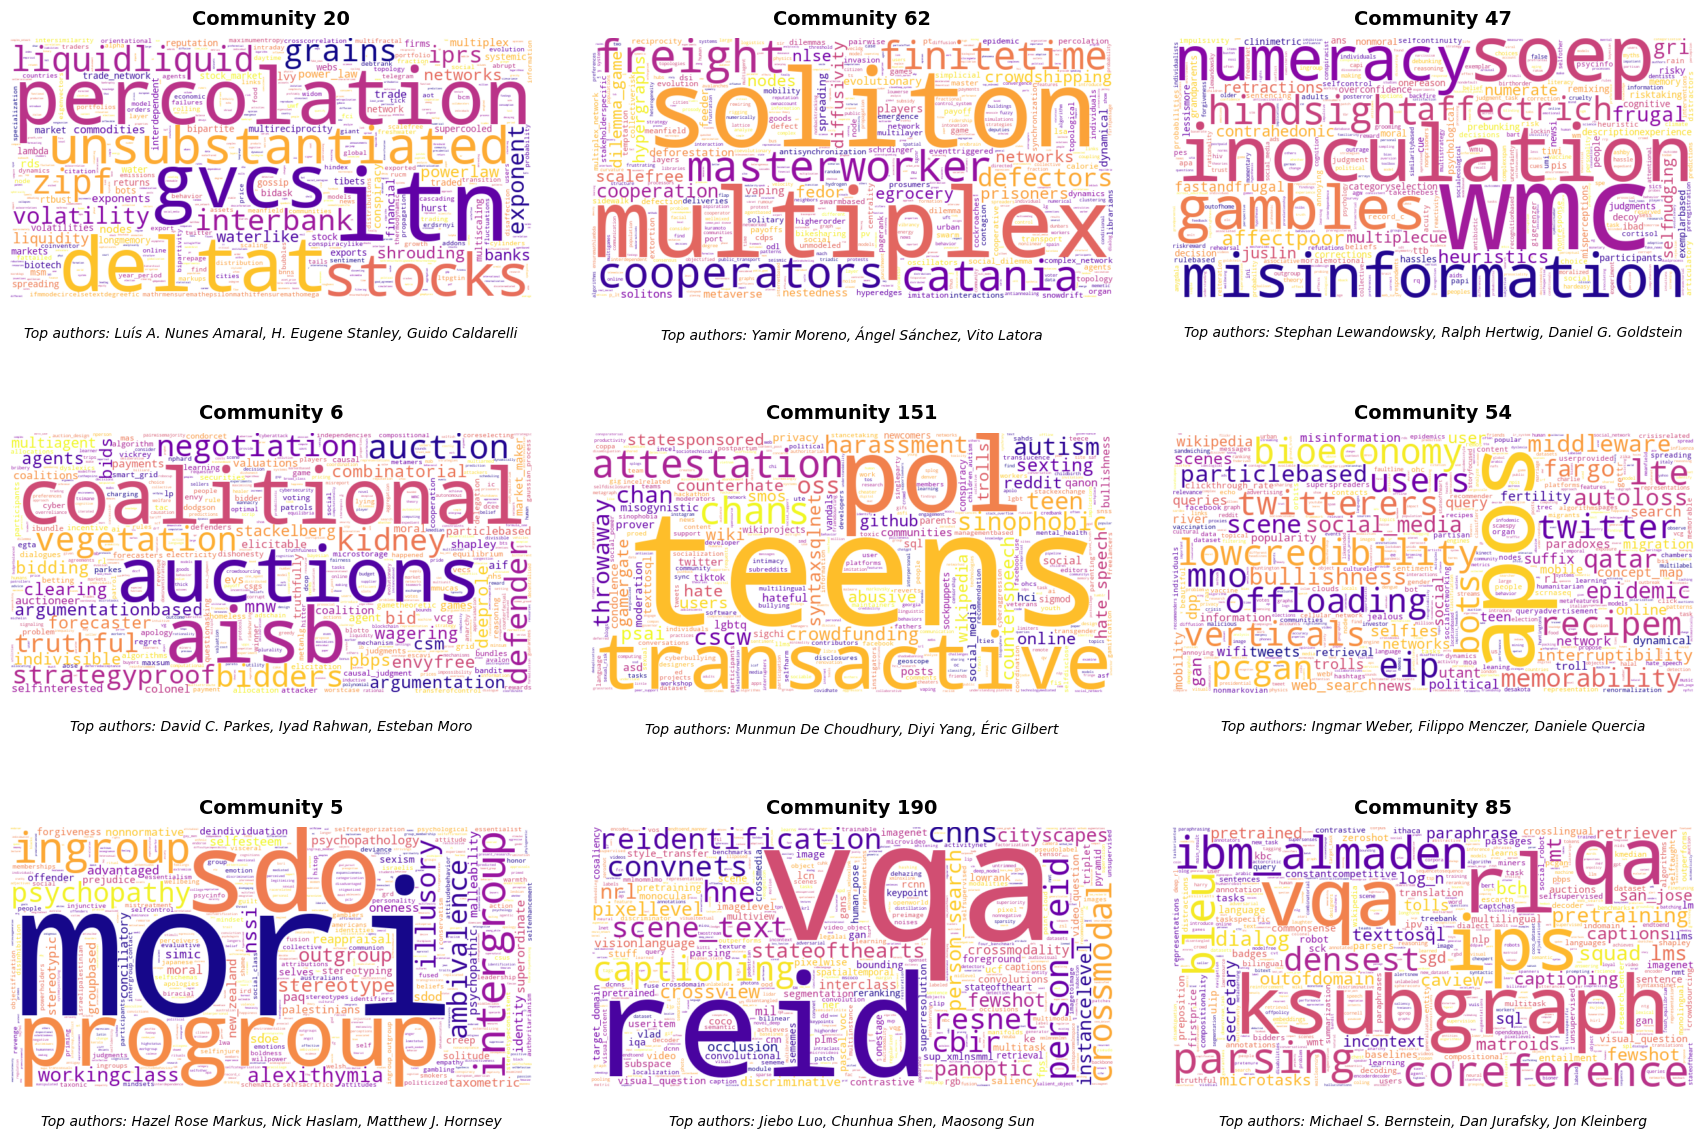

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i,id in enumerate(top_9_id_list):
    ax = axes[i]

    items = TFIDF[id].items()
    authors = top_9_id_dict[id]["authors"]

    terms_dict = {
        word: float(score)
        for word, score in items   
        if score > 0
    }

   # Create a nicer word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='plasma',          
        contour_width=1,
        contour_color='black',
        max_words=500
    ).generate_from_frequencies(terms_dict)
    
    # Plot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    
    # Format authors nicely (shorten if needed)
    authors_str = ", ".join(authors[:3])
    
    # Stylish title
    ax.set_title(
        f"Community {id}",
        fontsize=14,
        fontweight='bold',
        pad=10
    )
    
    # Subtitle (authors)
    ax.text(
        0.5, -0.1,
        f"Top authors: {authors_str}",
        ha='center',
        va='top',
        transform=ax.transAxes,
        fontsize=10,
        style='italic'
    )

# Remove empty subplots if <9 communities
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()